[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/4%20-%20PCA%20plus%20t-SNE/PCA_%2B_t_SNE_together.ipynb)

## Fetch data

In [0]:
!wget http://www.cl.cam.ac.uk/Research/DTG/attarchive/pub/data/att_faces.zip -O att_faces.zip
!unzip att_faces.zip

## Collect all image paths

In [3]:
import glob
imagepaths = glob.glob('**/*.pgm', recursive=True)
print(len(imagepaths))

400


## Create the dataset we need

In [0]:
import numpy as np
import pandas as pd
from scipy.misc import imread

faces = pd.DataFrame([])

individual_id = 0

for i, path in enumerate(imagepaths):
  print("===== loading image", i+1)
  img = imread(path)
  img = img.astype(np.uint8)
  img = img / 255
  img = img.flatten()
  data_entry = pd.DataFrame([img])
  data_entry['individual_id'] = individual_id
  if ((i+1)%10 == 0):    
    individual_id+=1  
  faces = faces.append(data_entry)

In [14]:
faces.head()

,0,1,2,3,4,5,6,7,8,9,...,10295,10296,10297,10298,10299,10300,10301,10302,10303,individual_id
0,0.466667,0.486275,0.462745,0.474510,0.466667,0.474510,0.462745,0.470588,0.474510,0.470588,...,0.309804,0.301961,0.305882,0.294118,0.321569,0.298039,0.294118,0.301961,0.321569,0
0,0.466667,0.474510,0.478431,0.470588,0.474510,0.474510,0.474510,0.482353,0.478431,0.466667,...,0.305882,0.313725,0.290196,0.309804,0.325490,0.309804,0.309804,0.313725,0.321569,0
0,0.439216,0.450980,0.470588,0.443137,0.470588,0.443137,0.466667,0.458824,0.454902,0.454902,...,0.215686,0.211765,0.184314,0.200000,0.192157,0.200000,0.207843,0.207843,0.211765,0
0,0.450980,0.443137,0.443137,0.462745,0.450980,0.458824,0.450980,0.458824,0.447059,0.454902,...,0.192157,0.227451,0.192157,0.215686,0.215686,0.196078,0.219608,0.203922,0.215686,0
0,0.447059,0.462745,0.447059,0.458824,0.447059,0.450980,0.450980,0.454902,0.447059,0.447059,...,0.203922,0.211765,0.168627,0.223529,0.215686,0.192157,0.211765,0.215686,0.203922,0


## Pull out the `individual_id` to identify individuals

In [15]:
individuals = faces['individual_id']
faces = faces.drop(['individual_id'], axis=1)
individuals.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39])

## Plot images

In [0]:
import matplotlib.pyplot as plt
from scipy.misc import imread

def plot_faces(data):
  fig, axes = plt.subplots(40, 10, figsize=(9, 41),
                           subplot_kw={'xticks':[], 'yticks':[]},
                           gridspec_kw=dict(hspace=0.01, 
                                            wspace=0.01))

  for i, ax in enumerate(axes.flat):
      ax.imshow(data.iloc[i].values.reshape(112, 92), cmap="gray")  

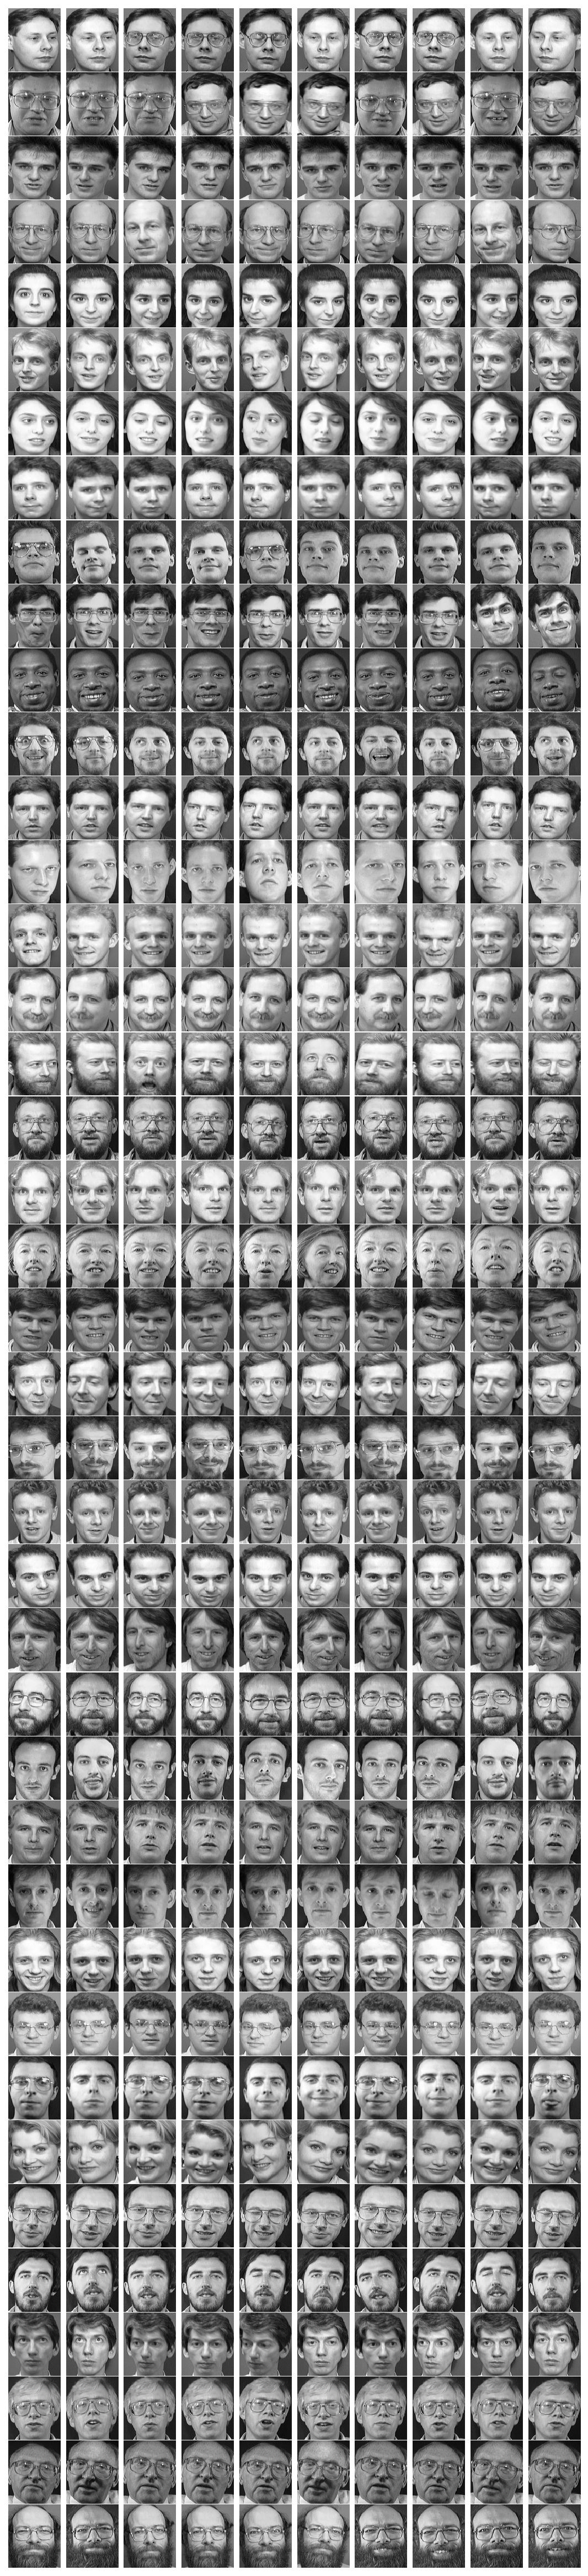

In [32]:
plot_faces(faces)

## Create a color for each of the 40 individuals

In [0]:
import random
r = lambda: random.randint(0,255)
random_colors = []
for i in range(0, len(individuals.unique())):
  random_colors.append('#%02X%02X%02X' % (r(),r(),r()))

colors = np.array(random_colors)[individuals]

## PCA

In [0]:
# PCA

from sklearn.decomposition import PCA

def run_pca(data, dimensions):
  pca = PCA(n_components=dimensions)
  pca.fit(data)
  pca_results = pca.transform(data)
  return pca_results

## 3D plot

In [0]:
from mpl_toolkits.mplot3d import Axes3D

def plot_3d(data, colors):    
  x, y, z = data.T
  fig = plt.figure(figsize=(10, 5.5/8*10))  
  ax = fig.add_subplot(111, projection='3d')
  ax.scatter(x, y, z, color=colors);

## PCA results

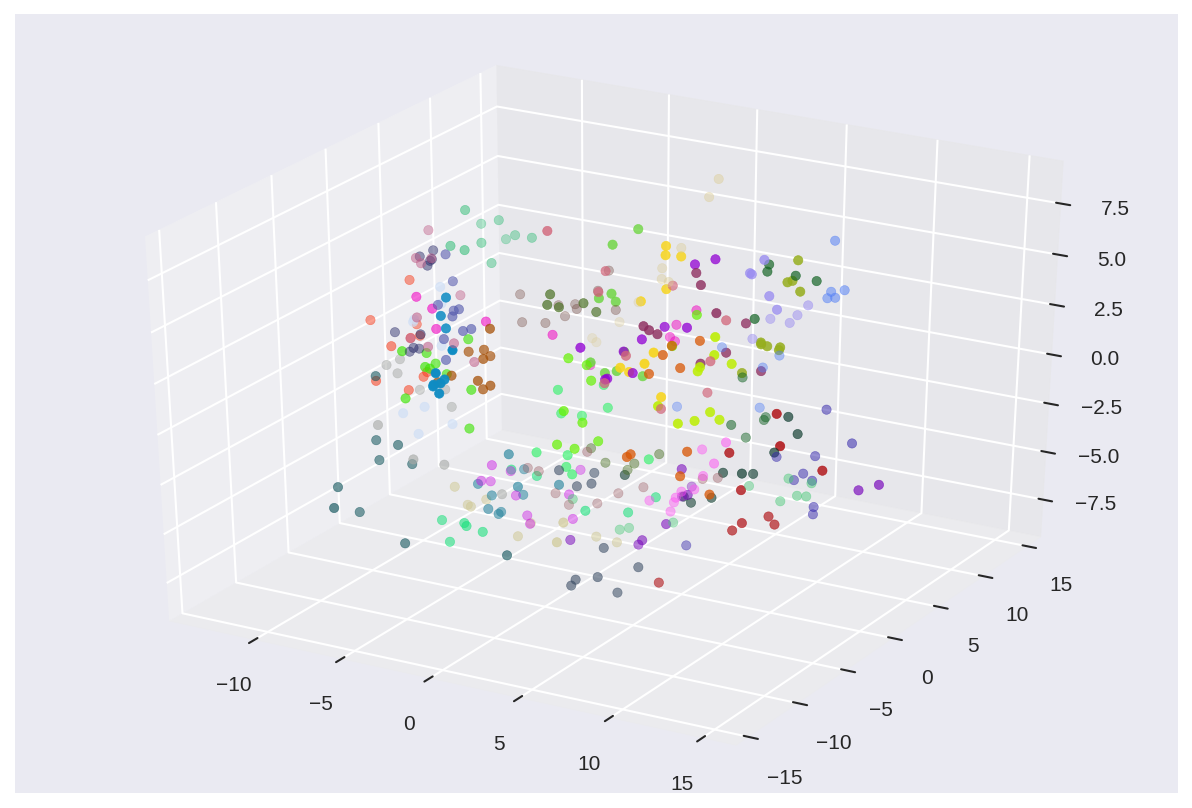

In [35]:
pca_results = run_pca(faces, 3)
plot_3d(pca_results, colors)

## t-SNE

In [0]:
# t-SNE

from sklearn.manifold import TSNE

def run_tsne(data, components):
  tsne = TSNE(n_components=components, 
              verbose=1, 
              perplexity=10,
              learning_rate=75.0)
  tsne_results = tsne.fit_transform(data)
  return tsne_results

## PCA + t-SNE results

[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 400 samples in 0.001s...
[t-SNE] Computed neighbors for 400 samples in 0.016s...
[t-SNE] Computed conditional probabilities for sample 400 / 400
[t-SNE] Mean sigma: 6.057595
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.294071
[t-SNE] Error after 1000 iterations: 0.295714


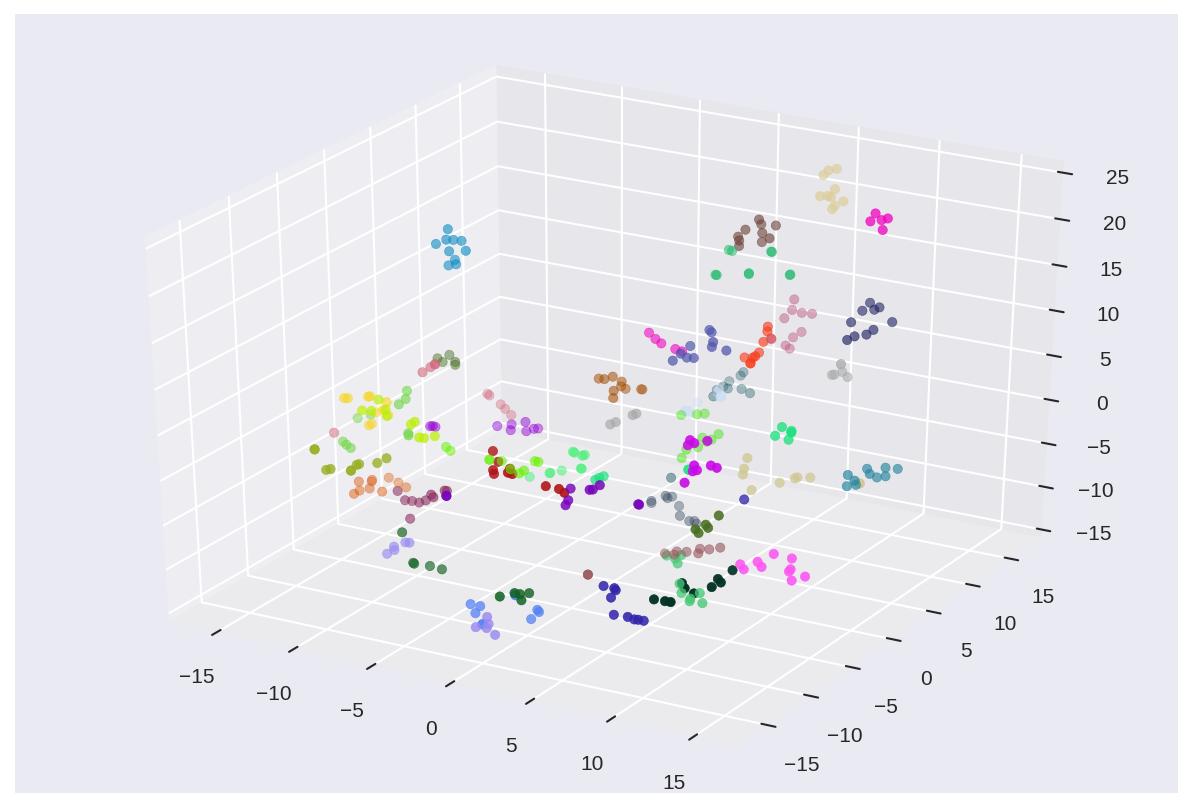

In [48]:
pca_results = run_pca(faces, 50)
results = run_tsne(pca_results, 3)
plot_3d(results, colors)